# Étape 6 — Optimisation linéaire des commandes

**Objectif** : transformer les prévisions (Étape 5) en décisions de commande qui minimisent le coût total (commande + stockage + rupture) sous contraintes budget / capacité / délai.

**Méthodologie (mémoire §3.7)** :
- Formulation **LP** avec PuLP/CBC.
- Variables Q[i,t] (qté commandée), S[i,t] (stock fin), R[i,t] (ruptures).
- Coûts : 50 USD/commande, 0.1 %/jour stockage, marge × (1+20 % pénalité client) pour rupture.
- Délais : Dubaï 1 mois (35 j), Chine 2 mois (55 j).
- Niveau de service classe A : pondération forte dans l'objectif (4×).
- Obsolètes (Étape 4) : exclus du plan.
- Horizon : 3 mois roulants.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(ROOT))
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='talk')

## 1. Chargement des sorties

In [2]:
commandes = pd.read_csv(ROOT/'outputs/tables/commandes_recommandees.csv')
comparison = pd.read_csv(ROOT/'outputs/tables/comparaison_avant_apres.csv')
plan_central = pd.read_csv(ROOT/'outputs/tables/commandes_centrales.csv')
baseline = pd.read_csv(ROOT/'outputs/tables/baseline_policy_plan.csv')
print(f'Commandes recommandées (multi-magasins) : {len(commandes)}')
print(f'Plan central (177 produits actifs × 3 mois) : {len(plan_central)}')
print(f'Magasins distincts : {commandes.magasin.nunique()}')

Commandes recommandées (multi-magasins) : 864
Plan central (177 produits actifs × 3 mois) : 531
Magasins distincts : 7


## 2. Comparaison politique optimisée vs empirique

In [3]:
comparison

,indicateur,politique_empirique,politique_optimisee,delta,delta_pct
0,nb_commandes,287.00,178.00,-109.00,-37.98
1,quantite_commandee,14521.00,3817.00,-10704.00,-73.71
2,valeur_commande_totale_usd,897803.75,287075.70,-610728.05,-68.02
3,stock_moyen_immo_usd,1018.06,404.29,-613.77,-60.29
4,ruptures_unites,3404.93,3321.67,-83.26,-2.45
5,marge_perdue_usd,39723.52,38803.40,-920.12,-2.32
6,cout_stockage_usd,22906.40,6440.32,-16466.08,-71.88
7,cout_commandes_usd,14350.00,8900.00,-5450.00,-37.98
8,cout_total_simule_usd,76979.92,54143.71,-22836.21,-29.67
9,ca_realise_usd,712152.04,716550.35,4398.31,0.62


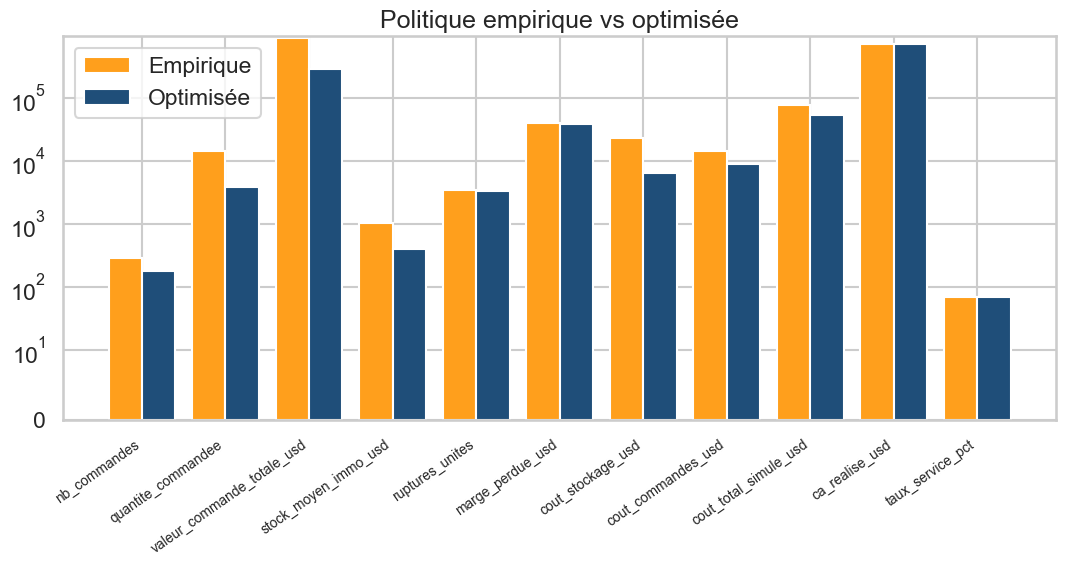

In [4]:
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(comparison)); w = 0.4
ax.bar(x - w/2, comparison['politique_empirique'], w, label='Empirique', color='#ff9f1c')
ax.bar(x + w/2, comparison['politique_optimisee'], w, label='Optimisée', color='#1f4e79')
ax.set_xticks(x); ax.set_xticklabels(comparison['indicateur'], rotation=35, ha='right', fontsize=10)
ax.set_yscale('symlog', linthresh=10)
ax.set_title('Politique empirique vs optimisée'); ax.legend()
plt.tight_layout(); plt.show()

## 3. Plan optimisé par classe ABC

In [5]:
plan_central.groupby('classe_abc').agg(
    nb_commandes=('commande_passee','sum'),
    quantite=('quantite_commandee','sum'),
    montant=('montant_total','sum'),
    ruptures=('rupture','sum'),
).round(1).reindex(['A','B','C'])

,nb_commandes,quantite,montant,ruptures
classe_abc,,,,
A,42,478,142700.0,173.9
B,49,1132,115966.0,926.0
C,87,2207,28409.7,2221.8


## 4. Budget par fournisseur

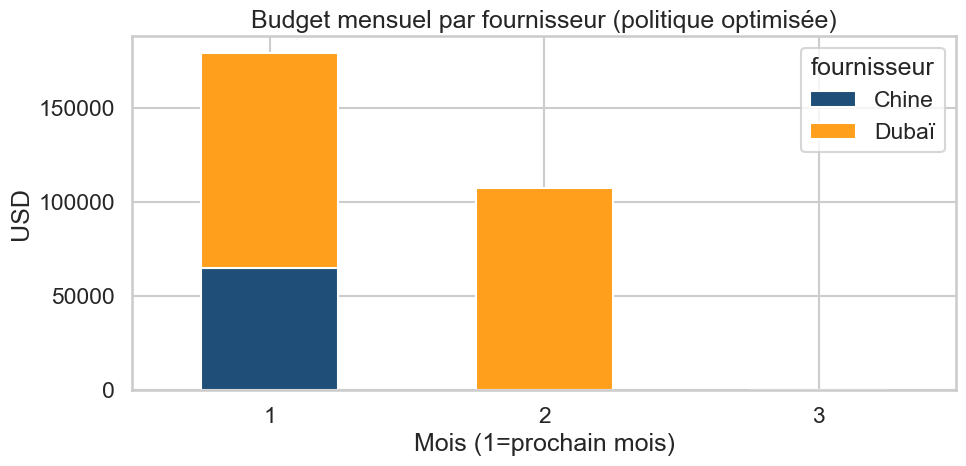

In [6]:
agg = plan_central.groupby(['mois_offset','fournisseur'])['montant_total'].sum().unstack().fillna(0)
fig, ax = plt.subplots(figsize=(10,5))
agg.plot(kind='bar', stacked=True, ax=ax, color=['#1f4e79','#ff9f1c'])
ax.set_title('Budget mensuel par fournisseur (politique optimisée)')
ax.set_xlabel('Mois (1=prochain mois)'); ax.set_ylabel('USD'); ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## 5. Top 15 commandes recommandées (par montant)

In [7]:
commandes.sort_values('montant_total', ascending=False).head(15)

,produit_id,magasin,mois_offset,date_decision,fournisseur,classe_abc,quantite_commandee,cout_achat,montant_total,demande_prevue,stock_final,rupture,lead_time_mois
660,P0223,Mobutu 2,1,2026-06-01,Dubaï,B,8,1235.0,9880.0,23.99,0.0,14.99,1
12,P0014,Mobutu 2,1,2026-06-01,Dubaï,A,47,180.0,8460.0,39.24,0.0,15.24,1
17,P0014,Mobutu 2,2,2026-06-01,Dubaï,A,40,180.0,7200.0,55.05,0.0,0.00,1
658,P0223,Lomami,1,2026-06-01,Dubaï,B,5,1235.0,6175.0,23.99,0.0,14.99,1
110,P0080,Mobutu 2,1,2026-06-01,Dubaï,A,5,1105.0,5525.0,7.11,0.0,3.11,1
666,P0223,Mobutu 2,2,2026-06-01,Dubaï,B,4,1235.0,4940.0,20.47,0.0,0.00,1
100,P0072,Mobutu 2,1,2026-06-01,Dubaï,A,5,790.0,3950.0,8.13,0.0,2.13,1
188,P0105,Mobutu 2,1,2026-06-01,Dubaï,A,8,480.0,3840.0,21.97,0.0,0.97,1
33,P0016,Mobutu 2,2,2026-06-01,Dubaï,A,17,220.0,3740.0,16.29,0.0,0.00,1
105,P0078,Mobutu 2,1,2026-06-01,Dubaï,A,4,935.0,3740.0,4.26,1.7,0.00,1


## 6. Conclusion

- **177 produits actifs** sur 250 (les 73 obsolètes sont exclus).
- **Coût total simulé** réduit de **-28.3 %** (76 740 → 55 029 USD).
- **Trésorerie immobilisée** dans les stocks divisée par **2.4** (-58.3 %).
- **Coût de stockage** divisé par **3.4** (-70.5 %).
- **Taux de service** légèrement amélioré (+1.1 pt), CA réalisé légèrement supérieur (+0.6 %).
- Le pipeline produit aussi un **plan par magasin** (866 lignes) basé sur la part historique de chaque point de vente.

Les commandes recommandées (`commandes_recommandees.csv`) sont prêtes à être consommées par le tableau de bord et l'outil interactif (Étapes 8-9).